# E-Commerce Customer Analytics — Exploratory Data Analysis

**Phase 2 of 4** in this project (SQL Cleaning → **EDA** → Customer Segmentation → Classification Modeling).

This notebook explores the cleaned e-commerce dataset (`../data/processed/ecommerce_sales_cleaned.csv`) produced by the SQL cleaning script in `../sql/01_data_cleaning.sql`. The goal is to understand distributions, relationships between order attributes, and early return/spend patterns before moving into segmentation and modeling.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Color palette used consistently across every phase of this project
# (SQL output -> Power BI dashboard -> these notebooks), so the whole
# portfolio piece reads as one connected body of work.
NAVY, TEAL, AMBER, GREY = "#1F3040", "#1B8A85", "#E8AC1F", "#9AA5B1"
PALETTE = [NAVY, TEAL, AMBER, GREY, "#6B7B8C"]

sns.set_theme(style="whitegrid")
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110

def money_axis(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M" if abs(x) >= 1e6 else f"${x/1e3:.0f}K")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)

In [1]:
sales = pd.read_csv("../data/processed/ecommerce_sales_cleaned.csv", parse_dates=["order_date"])
customers = pd.read_csv("../data/processed/customer_summary.csv", parse_dates=["first_order_date", "last_order_date"])
sales["order_month"] = sales["order_date"].dt.to_period("M").dt.to_timestamp()

print(f"Sales table:     {sales.shape[0]} rows x {sales.shape[1]} columns")
print(f"Customers table: {customers.shape[0]} rows x {customers.shape[1]} columns")
print(f"Date range: {sales['order_date'].min().date()} to {sales['order_date'].max().date()}")

Sales table:     1000 rows x 13 columns
Customers table: 292 rows x 12 columns
Date range: 2023-01-01 to 2024-01-03


## 1. Data Overview

1,000 individual orders across 292 unique customers, spanning just over one year. Before looking at any relationships, a quick check of the numeric fields:

In [1]:
sales[['unit_price','quantity','total_price','shipping_fee','age']].describe().round(2)

       unit_price     quantity  total_price  shipping_fee          age
count  1000.000000  1000.000000  1000.000000   1000.000000   900.000000
mean    331.933595     3.006000  1042.837000     10.033770    41.987778
std     418.203399     1.409732  1198.745442      4.336715    14.938441
min      15.000000     1.000000    15.000000      5.000000    18.000000
25%     100.000000     2.000000   300.000000      6.480000    29.000000
50%     200.000000     3.000000   600.000000      9.235000    42.000000
75%     300.000000     4.000000  1200.000000     13.310000    55.000000
max    2076.809461     5.000000  8307.237980     19.980000    69.000000


## 2. Univariate Analysis

Distributions of the core numeric fields, and counts across the main categorical fields.

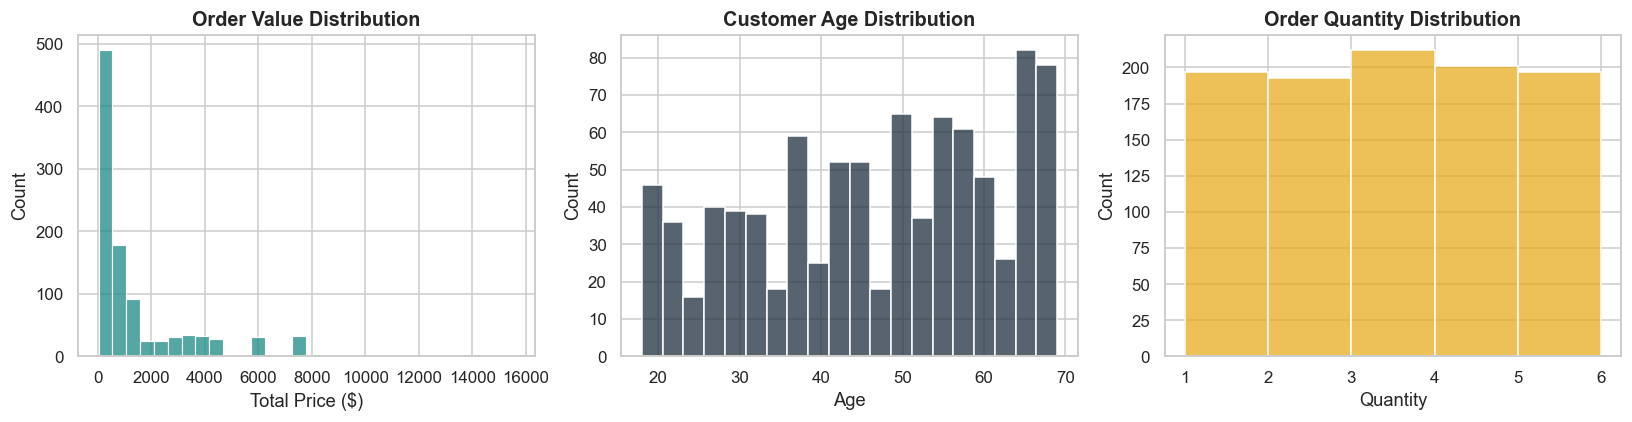

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(sales["total_price"], bins=30, color=TEAL, ax=axes[0])
axes[0].set_title("Order Value Distribution"); axes[0].set_xlabel("Total Price ($)")
sns.histplot(sales["age"].dropna(), bins=20, color=NAVY, ax=axes[1])
axes[1].set_title("Customer Age Distribution"); axes[1].set_xlabel("Age")
sns.histplot(sales["quantity"], bins=range(1, 7), color=AMBER, ax=axes[2])
axes[2].set_title("Order Quantity Distribution"); axes[2].set_xlabel("Quantity")
plt.tight_layout(); plt.show()

Return rate overall: 30.8 %


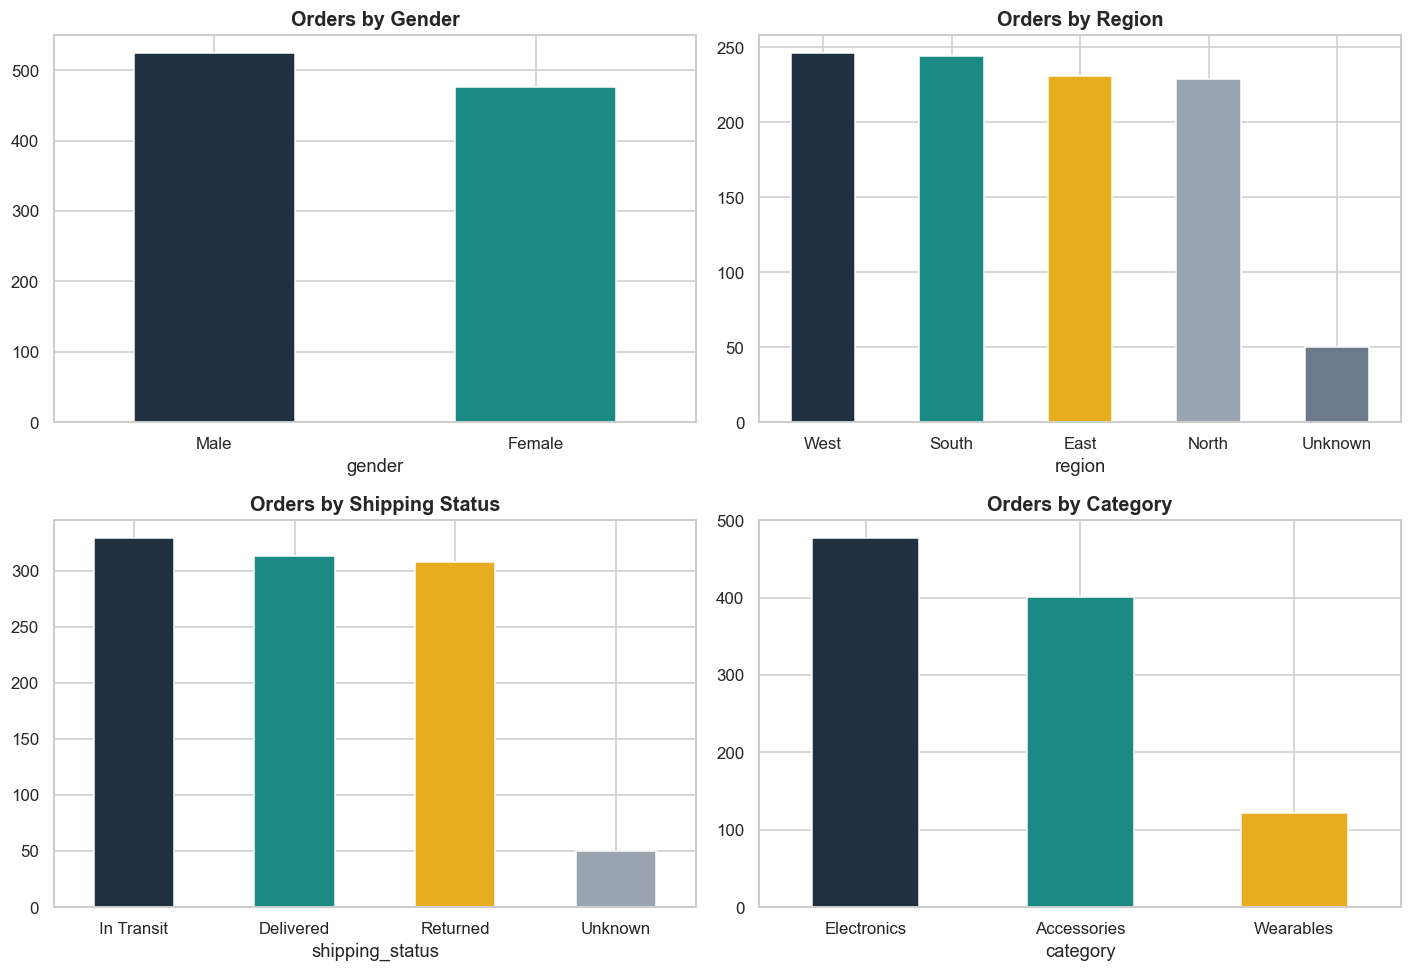

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sales["gender"].value_counts().plot(kind="bar", color=[NAVY, TEAL], ax=axes[0,0]); axes[0,0].set_title("Orders by Gender"); axes[0,0].tick_params(axis="x", rotation=0)
sales["region"].value_counts().plot(kind="bar", color=PALETTE, ax=axes[0,1]); axes[0,1].set_title("Orders by Region"); axes[0,1].tick_params(axis="x", rotation=0)
sales["shipping_status"].value_counts().plot(kind="bar", color=PALETTE, ax=axes[1,0]); axes[1,0].set_title("Orders by Shipping Status"); axes[1,0].tick_params(axis="x", rotation=0)
sales["category"].value_counts().plot(kind="bar", color=PALETTE, ax=axes[1,1]); axes[1,1].set_title("Orders by Category"); axes[1,1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

print("Return rate overall:", round((sales["shipping_status"] == "Returned").mean() * 100, 1), "%")

## 3. Bivariate / Relationship Analysis

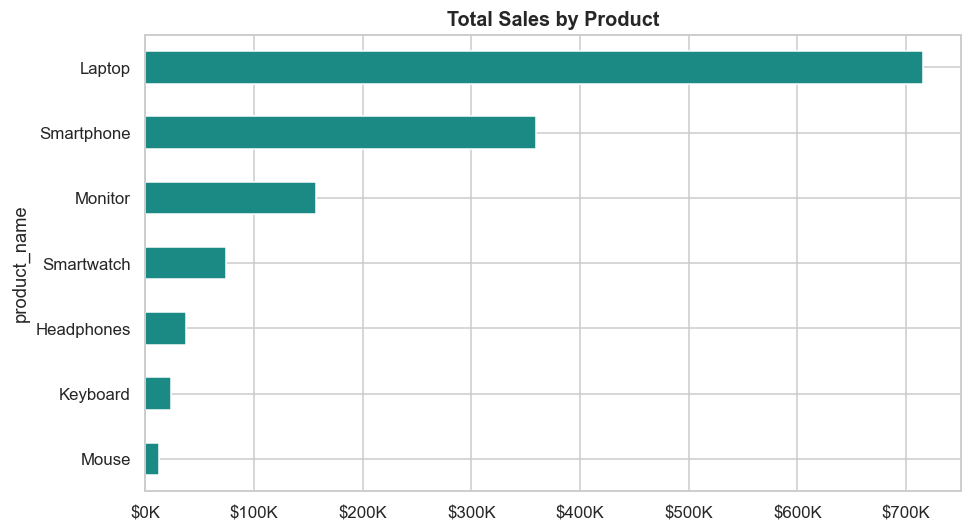

In [1]:
fig, ax = plt.subplots(figsize=(9, 5))
sales.groupby("product_name")["total_price"].sum().sort_values().plot(kind="barh", color=TEAL, ax=ax)
ax.set_title("Total Sales by Product"); money_axis(ax, axis="x")
plt.tight_layout(); plt.show()

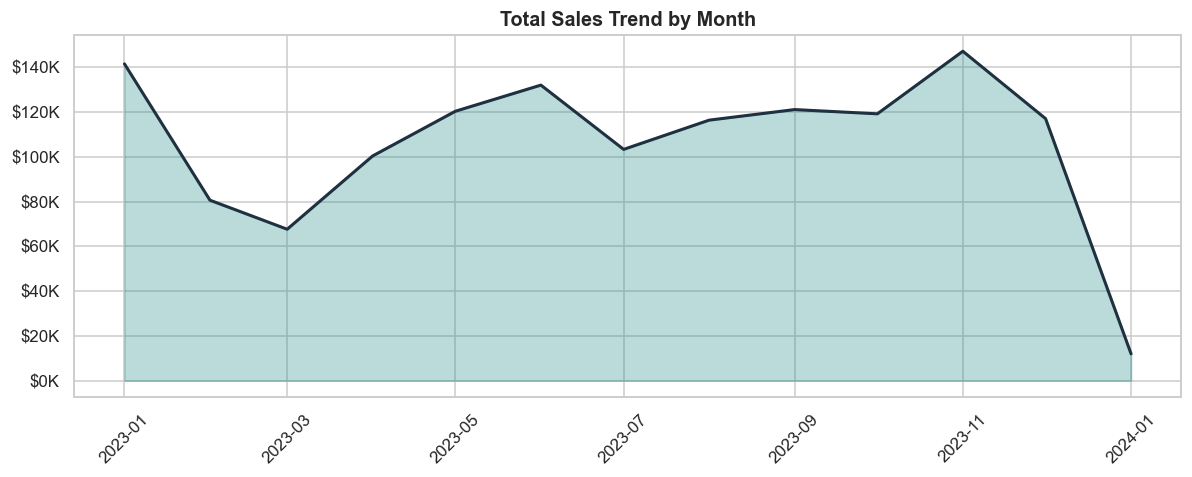

In [1]:
fig, ax = plt.subplots(figsize=(11, 4.5))
monthly = sales.groupby("order_month")["total_price"].sum()
ax.fill_between(monthly.index, monthly.values, color=TEAL, alpha=0.3)
ax.plot(monthly.index, monthly.values, color=NAVY, linewidth=2)
ax.set_title("Total Sales Trend by Month"); money_axis(ax)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

Correlation between the numeric fields — a quick sanity check before modeling later:

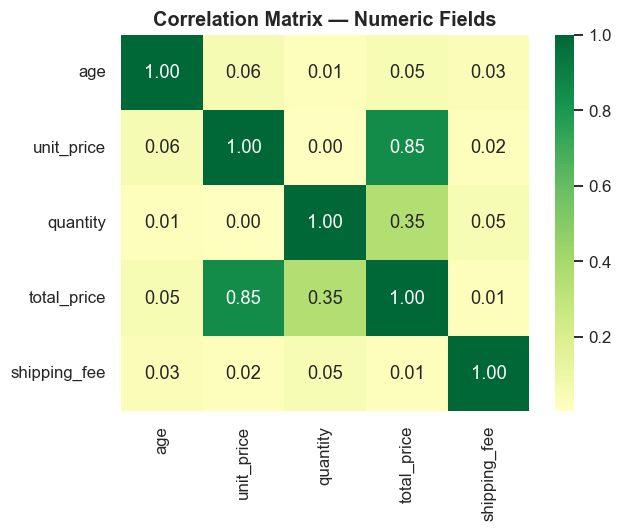

In [1]:
fig, ax = plt.subplots(figsize=(6, 5))
numeric_cols = ["age", "unit_price", "quantity", "total_price", "shipping_fee"]
corr = sales[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=ax)
ax.set_title("Correlation Matrix — Numeric Fields")
plt.tight_layout(); plt.show()

**Notable:** `age` barely correlates with `total_price` (~0.05) — age isn't a useful spend predictor in this dataset. `unit_price` and `total_price` correlate strongly (0.85, expected, since total is derived from it), and `quantity` moderately (0.35).

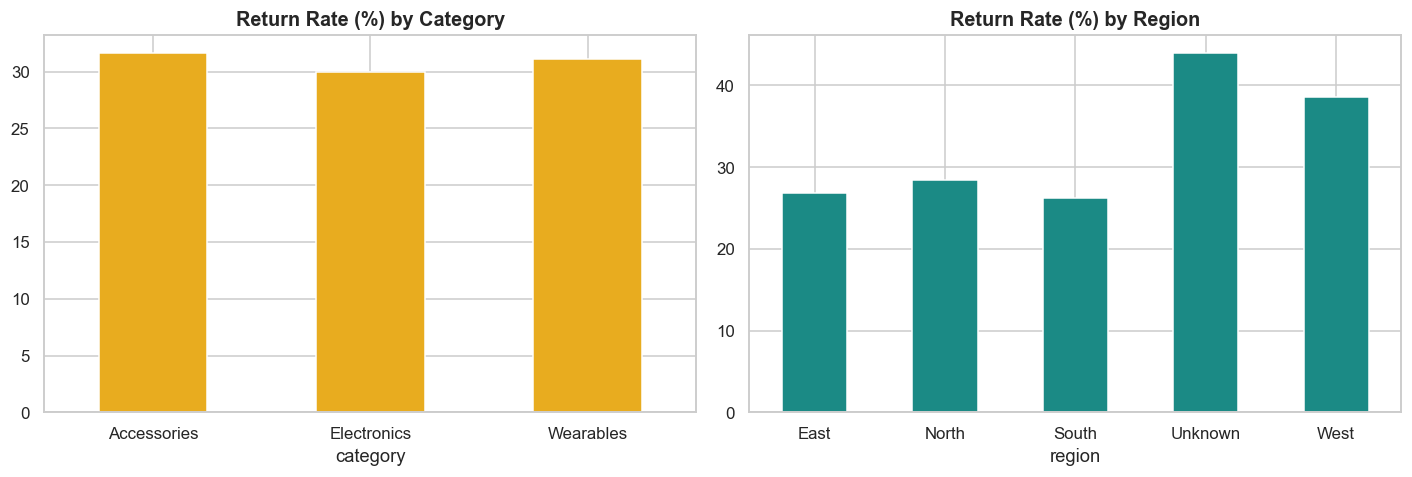

In [1]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sales.groupby("category")["shipping_status"].apply(lambda x: (x=="Returned").mean()*100).plot(kind="bar", color=AMBER, ax=axes[0])
axes[0].set_title("Return Rate (%) by Category"); axes[0].tick_params(axis="x", rotation=0)
sales.groupby("region")["shipping_status"].apply(lambda x: (x=="Returned").mean()*100).plot(kind="bar", color=TEAL, ax=axes[1])
axes[1].set_title("Return Rate (%) by Region"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

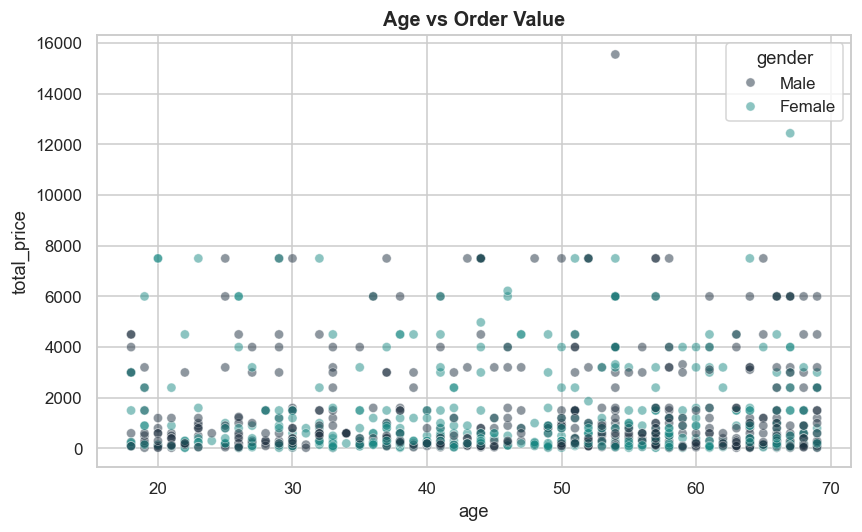

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=sales, x="age", y="total_price", hue="gender", palette=[NAVY, TEAL], alpha=0.5, ax=ax)
ax.set_title("Age vs Order Value")
plt.tight_layout(); plt.show()

## 4. Customer-Level Analysis

Switching from order-level to customer-level (`customer_summary.csv`, 292 rows).

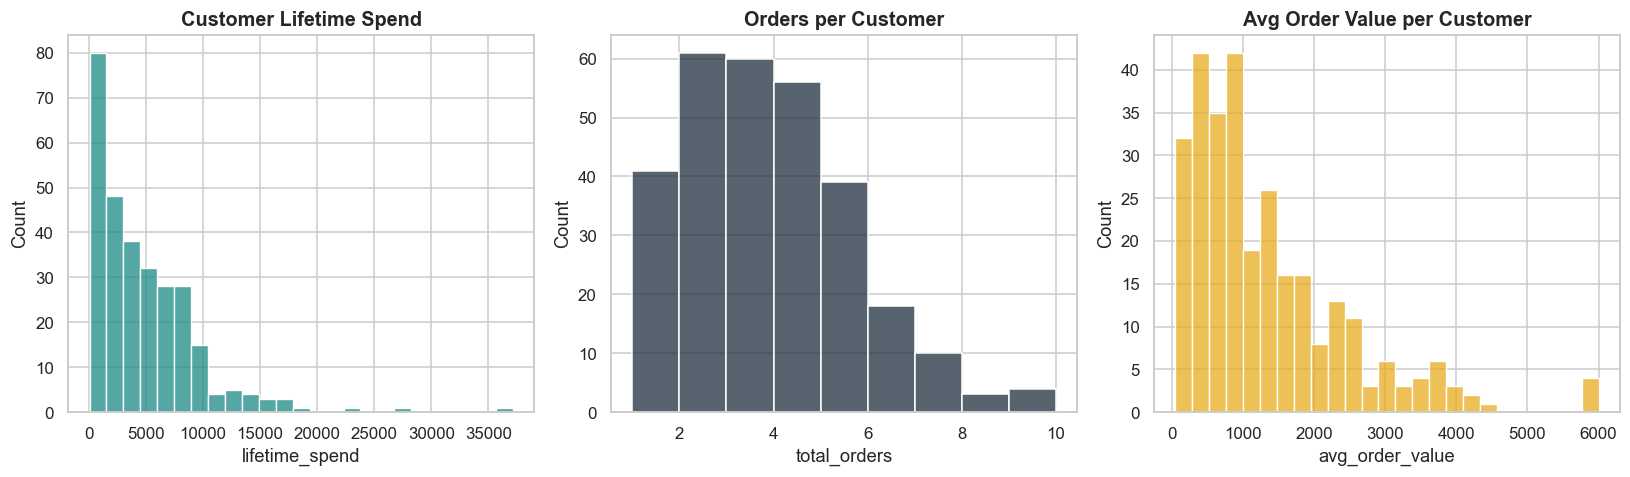

In [1]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(customers["lifetime_spend"], bins=25, color=TEAL, ax=axes[0]); axes[0].set_title("Customer Lifetime Spend")
sns.histplot(customers["total_orders"], bins=range(1, customers["total_orders"].max()+2), color=NAVY, ax=axes[1]); axes[1].set_title("Orders per Customer")
sns.histplot(customers["avg_order_value"], bins=25, color=AMBER, ax=axes[2]); axes[2].set_title("Avg Order Value per Customer")
plt.tight_layout(); plt.show()

Repeat customer rate: 86.0%


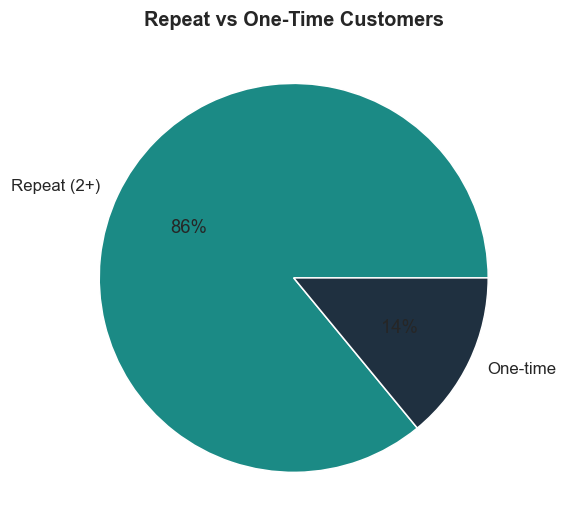

In [1]:
fig, ax = plt.subplots(figsize=(6, 5))
repeat_flag = customers["total_orders"].apply(lambda x: "Repeat (2+)" if x > 1 else "One-time")
repeat_flag.value_counts().plot(kind="pie", autopct="%1.0f%%", colors=[TEAL, NAVY], ylabel="", ax=ax)
ax.set_title("Repeat vs One-Time Customers")
plt.tight_layout(); plt.show()

print(f"Repeat customer rate: {(customers['total_orders'] > 1).mean()*100:.1f}%")

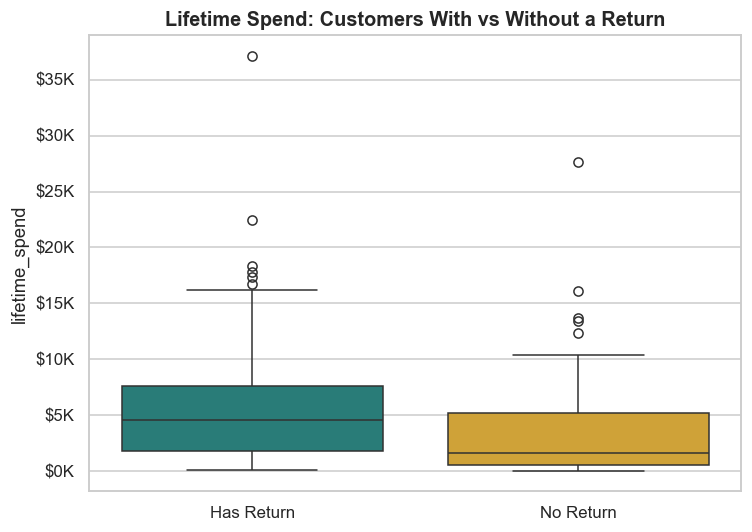

In [1]:
fig, ax = plt.subplots(figsize=(7, 5))
customers2 = customers.copy()
customers2["return_status"] = customers2["has_return_flag"].map({False: "No Return", True: "Has Return"})
sns.boxplot(data=customers2, x="return_status", y="lifetime_spend", hue="return_status", palette=[TEAL, AMBER], legend=False, ax=ax)
ax.set_title("Lifetime Spend: Customers With vs Without a Return")
ax.set_xlabel(""); money_axis(ax)
plt.tight_layout(); plt.show()

## Key Findings

- **Age is not a meaningful predictor of spend** — near-zero correlation (0.05) with order value.
- **30.8% overall return rate** — high enough to be worth investigating further (see the classification notebook for what was actually learned trying to predict this).
- **86% of customers are repeat buyers**, and spend is concentrated at the top of the distribution.
- Return status does not appear to relate to gender, region, category, or price in any way that survives statistical testing (confirmed rigorously in the classification notebook).

**Next:** `02_customer_segmentation.ipynb` — grouping customers into actionable segments using RFM + K-Means.